In [1]:
import numpy as np
import pandas as pd
import  matplotlib.pyplot  as plt
import seaborn as sns

In [146]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 1. Generate large dataset
np.random.seed(42)
n_samples = 15000

df = pd.DataFrame({
    'age': np.random.randint(18, 65, size=n_samples),
    'income': np.random.randint(20000, 150000, size=n_samples),
    'education': np.random.choice(['HighSchool', 'Bachelors'], size=n_samples),  # 2 categories
    'region': np.random.choice(['Urban', 'Rural'], size=n_samples),              # 2 categories
    'job': np.random.choice(['Tech', 'Sales'], size=n_samples)                   # 2 categories
})

# 2. Rule-based target to induce overfitting
df['target'] = (
    (df['age'] < 30) &
    (df['income'] > 80000) &
    (df['education'] == 'Bachelors') &
    (df['region'] == 'Urban') &
    (df['job'] == 'Tech')
).astype(int)

# 3. Define columns
cat_cols = ['education', 'region', 'job']
num_cols = ['age', 'income']
target = 'target'

# 4. Encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), cat_cols)
    ],
    remainder='passthrough'
)

X = df.drop(target, axis=1)
y = df[target]
X_encoded = preprocessor.fit_transform(X)
X_encoded = pd.DataFrame(X_encoded, columns=cat_cols + num_cols)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)




In [144]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [148]:
model = DecisionTreeClassifier(criterion="gini" )
model.fit(X_train , y_train)
print(model.score(X_train  , y_train))
print(model.score(X_test  , y_test))



1.0
1.0


In [150]:
from sklearn.model_selection import GridSearchCV , cross_val_score

In [159]:
parameters = {
    "criterion": ['gini', 'entropy', 'log_loss'],
    "splitter": ['best', 'random'],
    "max_depth": [1, 2, 3, 4, 5],  # ✅ correct spelling
    "max_features": [None, 'sqrt', 'log2']
}


In [160]:
tr = DecisionTreeClassifier(max_depth = 2)

In [161]:
CV = GridSearchCV(tr ,param_grid=parameters , cv  = 5 ,scoring ="accuracy")

In [162]:
CV.fit(X_train  , y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=2),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': [None, 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [163]:
CV.best_params_

{'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'splitter': 'best'}

# PRACTISE

In [196]:
import numpy  as np
import pandas as pd


In [197]:
from sklearn.datasets import load_iris

In [198]:
iris = load_iris()
df = pd.DataFrame(iris.data , columns = iris.feature_names)
ser = pd.Series(iris.target )
df['target']= ser


In [199]:
from  sklearn.model_selection import train_test_split , GridSearchCV

In [200]:
x1,x2,y1,y2=train_test_split(df.iloc[:,:-1] , df.iloc[:,-1] , test_size = 0.3  , random_state=12 , stratify =  df.iloc[:,-1])

In [201]:
from sklearn.tree import DecisionTreeClassifier , DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier ,  KNeighborsRegressor
from sklearn.linear_model import LogisticRegression , LinearRegression , Ridge ,SGDRegressor , Lasso , ElasticNet
from sklearn.metrics import accuracy_score ,  recall_score  , precision_score , confusion_matrix

0.9523809523809523
0.9555555555555556


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


<Axes: >

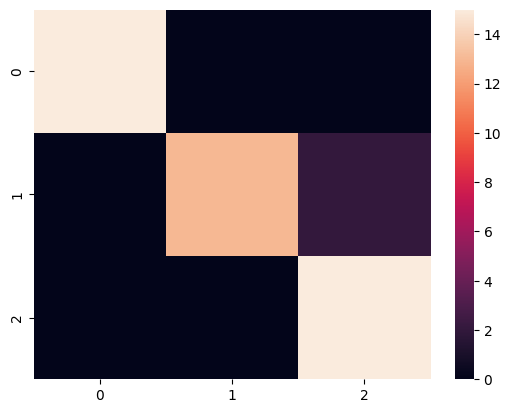

In [202]:
# usng logistic Regression
import seaborn as sns
lr = LogisticRegression(max_iter =  1000  , multi_class ='ovr' )
lr.fit(x1,y1)
print(accuracy_score(y1,lr.predict(x1)))
print(accuracy_score(y2,lr.predict(x2)))

sns.heatmap(confusion_matrix(y2 , lr.predict(x2)))

In [203]:
params ={
    'penalty' : [None ,'l1'],
    'tol' : [0.01,0.001],
    'max_iter' : [100,1000]


}

In [204]:
sc = GridSearchCV(estimator=lr ,param_grid=params , cv = 5  , scoring ="accuracy" , n_jobs = -1  )

In [205]:
sc.fit(x1 , y1)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, multi_class='ovr'),
             n_jobs=-1,
             param_grid={'max_iter': [100, 1000], 'penalty': [None, 'l1'],
                         'tol': [0.01, 0.001]},
             scoring='accuracy')

In [206]:
sc.best_params_
print(sc.best_score_)

0.9523809523809523


In [207]:
from sklearn.metrics import classification_report  as report
print(report(y2 , lr.predict(x2)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.87      0.93        15
           2       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [208]:
from sklearn.metrics import precision_score ,f1_score
precision_score(y2 , lr.predict(x2) , average ='macro')

0.9607843137254902

In [209]:
from sklearn.metrics import roc_auc_score  , roc_curve


In [210]:
# roc_auc_score(y2 , lr.)


In [211]:
from sklearn.model_selection import learning_curve

In [212]:
size , train_Score  , test_score = learning_curve(lr, x1 , y1 , cv =5 , scoring ="neg_mean_squared_error" , train_sizes = np.linspace(0.1 , 1.0 ,5))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

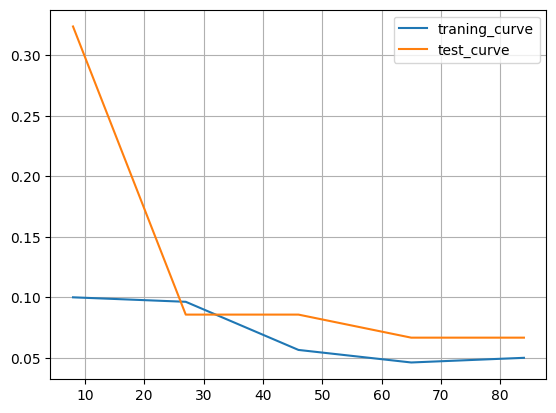

In [213]:
t1 = -np.mean(train_Score , axis =1)
t2 = -np.mean(test_score , axis =1)
# train_Score  , test_score
import matplotlib.pyplot as plt
plt.plot(size , t1, label = "traning_curve")
plt.plot(size , t2 , label ="test_curve")
plt.grid()
plt.legend()
plt.show()

In [214]:
knn = KNeighborsClassifier(n_neighbors = 2 , p =2 )
params  = {
    'n_neighbors': np.arange(2,40 , 1)
}
s= GridSearchCV(estimator = knn , param_grid=params , cv = 5 , scoring ="accuracy")
s.fit(x1 , y1)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=2),
             param_grid={'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39])},
             scoring='accuracy')

In [215]:
print(s.best_params_)
print(s.best_score_)

{'n_neighbors': np.int64(11)}
0.9619047619047618


In [216]:
l =  np.arange(2,20)
a =  [ ]
b = []
for i in l :
  knn = KNeighborsClassifier(n_neighbors = i , p =2 )
  knn.fit(x1,y1)
  a.append(accuracy_score(y1 , knn.predict(x1)) )
  b.append(accuracy_score(y2 , knn.predict(x2)) )


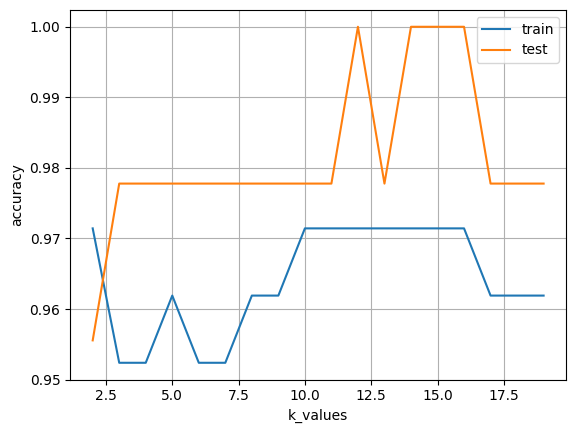

In [217]:
plt.plot(l ,a , label ="train")
plt.plot(l ,b , label ="test")
plt.xlabel("k_values")
plt.ylabel("accuracy")
plt.grid()
plt.legend()
plt.show()

In [218]:
from sklearn.model_selection import learning_curve
size , train_Score  , test_score = learning_curve(lr, x1 , y1 , cv =5 , scoring ="neg_mean_squared_error" , train_sizes = np.linspace(0.1 , 1.0 ,5))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

In [219]:
test_size , train_score , test_score =learning_curve(knn ,x1 , y1 ,cv=5 ,scoring  ="neg_mean_squared_error", train_sizes = np.linspace(0.1,1.0 ,5))

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

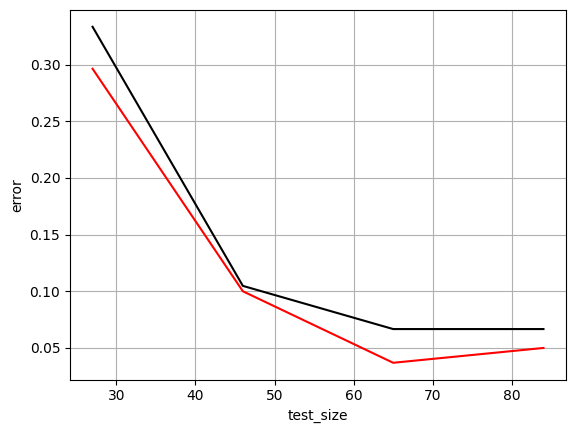

In [220]:
a = -np.mean(train_score , axis =  1)
b = -np.mean(test_score , axis =  1)
plt.plot(test_size , a , color ="red" ,  label ="train")
plt.plot(test_size , b , color ="black" ,  label ="test")
plt.xlabel("test_size")
plt.ylabel("error")
plt.grid()
plt.show()

In [221]:
model = tree()
model.fit(x1 , y1)
pred=model.predict(x2)
model.score(x2,y2)

0.9777777777777777

In [222]:
from sklearn.tree import plot_tree

In [226]:
params = {
    'max_depth' : [2,3,4,5, None ],
    "criterion" : ["gini" ,'entropy' ,'log_loss'] ,
    'splitter' :['best','random'],
    'min_samples_split' : [2,3,4,5]
}

In [224]:
ob = tree()
ob.fit(x1 , y1)

DecisionTreeClassifier()

In [228]:
t = GridSearchCV(estimator =  ob , cv =  5 ,param_grid=params, scoring = "accuracy")
t.fit(x1,y1)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 4, 5, None],
                         'min_samples_split': [2, 3, 4, 5],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [229]:
t.best_params_


{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_split': 2,
 'splitter': 'random'}

In [230]:
t.best_score_

np.float64(0.9619047619047618)

In [232]:
a=[]
b=[]
k =np.arange(1,6)
for i in k :
  ob = tree(max_depth = i)
  ob.fit(x1 , y1)
  a.append(ob.score(x1,y1))
  b.append(ob.score(x2,y2))


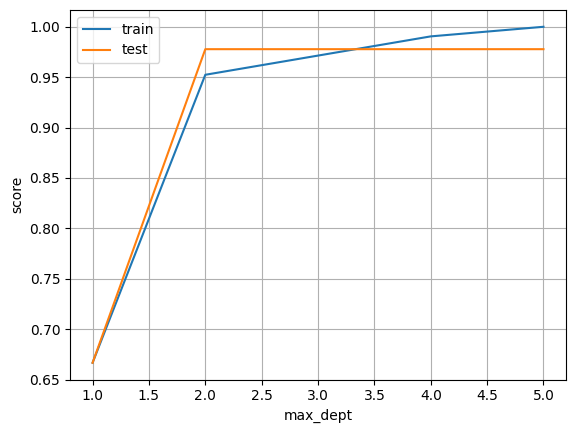

In [236]:
plt.plot(k , a , label= "train")
plt.plot(k , b , label= "test")
plt.legend()
plt.xlabel("max_dept")
plt.ylabel("score")
plt.grid()

plt.show()